# **Data Quality and Validation in ETL**

**Question 1** : Define Data Quality in the context of ETL pipelines. Why is it more than just data cleaning?

**solution:**



**Defining Data Quality in ETL**

In an ETL (Extract, Transform, Load) context, Data Quality is the measure of how well a dataset serves its intended purpose. It isn’t a single metric; rather, it’s a composite of several pillars:

**Accuracy:** Does the data reflect reality? (e.g., Is a customer’s age actually 35?)

**Completeness:** Are there missing values or "nulls" in critical fields?

**Consistency:** Does the data match across different systems? (e.g., Does "Active" in the CRM mean the same thing in the Data Warehouse?)

**Timeliness**: Is the data fresh enough to be useful for decision-making?

**Validity:** Does the data follow the required format or business rules? (e.g., Email addresses must contain an @ symbol).

**Why It’s More Than Just "Data Cleaning"**

Many people use "Data Quality" and "Data Cleaning" interchangeably, but cleaning is just one tactical step in a much larger strategic framework. Think of Cleaning as the medicine and Data Quality as the entire healthcare system.

**1. Proactive vs. Reactive**

**Data Cleaning** is reactive. It happens after the data is already messy. You find a null, you fill it; you find a duplicate, you delete it.

**Data Quality** involves proactive
Observability. It’s about building "circuit breakers" into your ETL pipeline so that if the data is bad at the source, the pipeline stops before that bad data corrupts your downstream dashboards.

**2. Root Cause Analysis**

Cleaning fixes the symptom (the broken record), but DQ looks for the root cause. If an ETL job fails because a source system changed its date format from MM/DD/YYYY to YYYY-MM-DD, simply "cleaning" the current batch doesn't solve the fact that every future batch will also be broken. DQ involves schema enforcement and contract management.

**3. Context and Business Logic**

Cleaning is often technical (fixing syntax), while DQ is context-dependent.

Example: A temperature reading of $150^\circ\text{C}$ is technically "clean" (it's a valid number). However, from a Data Quality perspective, if that sensor is inside a refrigerator, it is "low quality" because it is physically impossible. Cleaning can't tell you that; only a DQ rule defined by business logic can.

**4. The "Garbage In, Garbage Out"**

PreventionIn modern ETL, we often use Data Contracts. This moves DQ "upstream." Instead of cleaning data after it lands in your warehouse, DQ involves negotiating with the producers of the data to ensure they send it correctly in the first place.

**Question 2**: Explain why poor data quality leads to misleading dashboards and incorrect decisions.

**solutions:**

Here is an analysis of why this leads to misleading outcomes and poor choices:

**1. The "Garbage In, Garbage Out" (GIGO) Principle**

A dashboard is essentially a processing engine that transforms raw data into visual summaries. If the input data is inaccurate, incomplete, or outdated, the dashboard will faithfully visualize those errors.

**Misleading Visuals:** A bar chart showing a massive spike in sales might actually be reflecting duplicate entries rather than actual growth.

**False Trends:** Inconsistent data entry (e.g., using different date formats) can make a stable process look like it is fluctuating wildly, causing unnecessary panic.

**2. Erosion of "Single Source of Truth"**

Data quality issues often stem from fragmented data or conflicting definitions across departments.

**Contradictory Insights**: If the Marketing department defines a "lead" differently than the Sales department, a dashboard attempting to show conversion rates will produce a "Frankenstein" metric that satisfies neither.

**Decision Paralysis:** When stakeholders see two different numbers for the same KPI, they lose trust in the dashboard entirely, reverting to "gut feeling" rather than data-driven logic.

**3. Hidden Biases and Selection Issues**

Data quality isn't just about typos; it’s about completeness.

**Missing Dimensions:** If a dashboard tracks customer satisfaction but fails to capture data from a specific region or demographic due to a technical glitch, the resulting "90% satisfaction" score is a dangerous overestimation.

**Skewed Resource Allocation:** Management might decide to cut funding for a product line that appears underperforming on the dashboard, unaware that the "poor performance" is actually a result of missing transaction logs.

**4. Flawed Statistical Correlates**

Advanced dashboards often use data to imply causation or correlation (e.g., "Increased ad spend led to higher traffic").

**False Correlations:** Outliers—which are often just data entry errors—can heavily skew averages and correlation coefficients.

**Incorrect Forecasting:** Predictive models built on poor historical data will project future trends that are physically or economically impossible, leading to catastrophic inventory or hiring decisions.

**5. The Opportunity Cost of Re-Work**

When a decision is made based on a misleading dashboard, the cost isn't just the initial mistake. It includes:

**The "Trust Tax":** Once a dashboard is proven wrong, users will spend more time manually verifying data in spreadsheets than using the dashboard for its intended purpose.

**Reactive Management:** Instead of being proactive, leadership spends their time investigating "data ghosts"—anomalies in the dashboard that don't exist in reality.

**Question 3 :** What is duplicate data? Explain three causes in ETL pipelines.

**solution**:

Duplicate data refers to any instance where a single record or a specific piece of information exists multiple times in a dataset. In the context of data engineering, this means having two or more rows in a database that represent the same real-world entity or event (e.g., the same customer, the same transaction, or the same sensor reading).

**Three Causes of Duplicates in ETL Pipelines**

In an Extract, Transform, Load (ETL) process, data travels through various stages. Duplicates are rarely "organic"; they are typically the result of technical configurations or system failures within these stages.

**1. Non-Idempotent Job Retries**
One of the most common causes occurs during the Load phase when a pipeline fails midway through execution.

**The Scenario:** If a pipeline is designed to "append" data and it crashes after loading 50% of the records, a common automated response is to restart the job.

**The Result:** If the system doesn't check for existing records before restarting, it will reload the first 50% again, creating exact duplicates of those initial rows.

**The Fix:** Designing "idempotent" pipelines that use UPSERT logic (update if exists, insert if new) rather than simple INSERT.

**2. Lack of Distinct Joins or Fan-outs**

During the Transform phase, data from multiple sources is often combined using "joins."

**The Scenario:** If a developer joins a Sales table with a Product_Categories table using a ProductID, but the Product_Categories table accidentally contains multiple entries for the same ID (perhaps due to different historical versions), a "fan-out" occurs.

**The Result**: A single sales transaction will be multiplied for every matching row found in the category table, artificially inflating revenue figures in the final output.

**The Fix:** Using DISTINCT keywords or ensuring primary key uniqueness in reference tables before performing joins.

**3. Data Integration from Overlapping Sources**

In the Extract phase, pipelines often pull data from multiple upstream systems to create a unified view.

**The Scenario:** Consider a company that uses both a CRM (like Salesforce) and a separate billing system. If a customer exists in both systems under slightly different identifiers (e.g., "J. Doe" vs. "John Doe"), the ETL pipeline may extract both records.

**The Result:** Without a robust "deduplication" or "entity resolution" step in the transformation layer, the final data warehouse will treat these as two separate customers.

**The Fix:** Implementing "fuzzy matching" or master data management (MDM) rules to merge records that refer to the same entity.

**Question 4 :** Differentiate between exact, partial, and fuzzy duplicates.

**solution:**

**1. Exact Duplicates**

Exact duplicates occur when two or more records are identical across every single column or field in the dataset.

**Characteristics**: Every character, space, and digit is a perfect match. If you were to calculate a "hash" (a digital fingerprint) for both rows, the hashes would be identical.

**Typical Cause**: Usually caused by technical glitches in the ETL process, such as a data ingestion job running twice or a system failure during a "write" operation that wasn't properly rolled back.

**Example:**

Record A: 101 | John Smith | 555-0123 | New York

Record B: 101 | John Smith | 555-0123 | New York

**2. Partial Duplicates**

Partial duplicates occur when records share the same unique identifier or "key" but differ in their secondary information.

**Characteristics**: The primary identifier (like a Social Security Number, Email, or Transaction ID) matches, but other fields—such as address or phone number—contain different values.

**Typical Cause:** This often happens when a system maintains historical versions of a record (versioning) or when data is updated in one system but not another, leading to "stale" data competing with "fresh" data.

**Example:**

Record A: User_88 | Jane Doe | 123 Maple St | Active

Record B: User_88 | Jane Doe | 456 Oak Ave  | Inactive

**3. Fuzzy Duplicates**

Fuzzy duplicates occur when records refer to the same real-world entity but are not syntactically identical due to typos, formatting differences, or variations in naming.

**Characteristics:** These cannot be identified by simple matching logic. They require "fuzzy matching" algorithms (like Levenshtein distance) to calculate a similarity score.

**Typical Cause:** Human error during manual data entry is the primary culprit. This includes abbreviations, misspellings, or inconsistent use of punctuation.

**Example:**

Record A: Jonathon Smith | 5th Ave. | NY

Record B: John Smith | Fifth Avenue | New York City

**Question 5** : Why should data validation be performed during transformation rather than after loading?

**solution:**

Performing validation during transformation follows the "Shift Left" principle, preventing "dirty" data from ever reaching the final data warehouse. This saves storage costs, prevents users from seeing incorrect reports, and makes it easier to trace errors back to the source before the data is further aggregated.

**Question 6 :** Explain how business rules help in validating data accuracy. Give an example.


Use the following Sales_Transactions dataset for all questions:

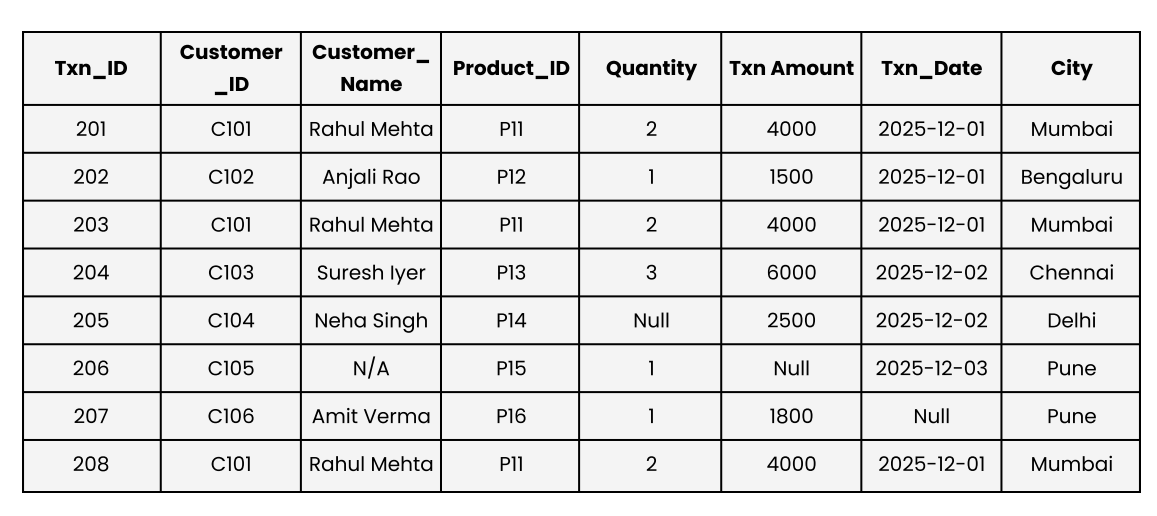



















**solution:**

Business rules are specific constraints defined by the organization to ensure data makes sense in a real-world context.  

**Example:** A business rule might state that Txn_Amount must always be greater than zero. If the Sales_Transactions table shows a transaction with a Null or negative amount (like Txn_ID 206), it is flagged as inaccurate.  

**Question 7**: Write an SQL query on Sales_Transactions to list all duplicate keys and their counts using the
business key (Customer_ID + Product_ID + Txn_Date + Txn_Amount )

**solution:**

SELECT Customer_ID, Product_ID, Txn_Date, [Txn Amount], COUNT(*) as Duplicate_Count

FROM Sales_Transactions

GROUP BY Customer_ID, Product_ID, Txn_Date, [Txn Amount]

HAVING COUNT(*) > 1;

**Question 8**: Enforcing Referential Integrity

Assume the following Customers_Master table:

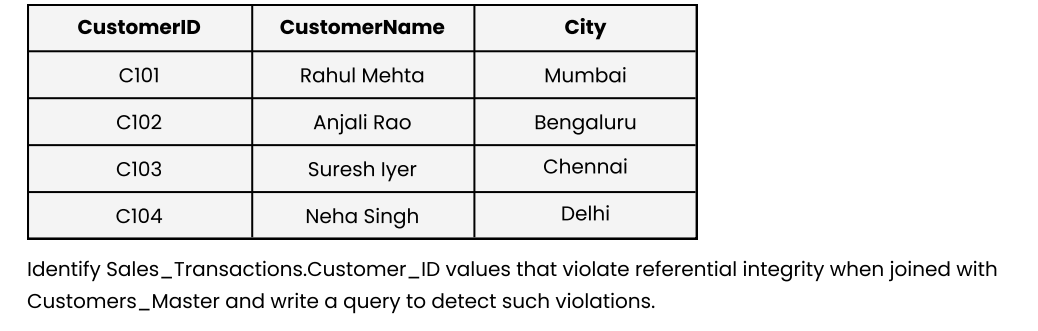

**solution:**

Referential integrity is violated when a Customer_ID in the Sales_Transactions table does not exist in the Customers_Master table.

**Violations:** C105 and C106 are present in the transactions but are missing from the Customers_Master table.  

SELECT DISTINCT st.Customer_ID

FROM Sales_Transactions st

LEFT JOIN Customers_Master cm ON st.Customer_ID = cm.CustomerID

WHERE cm.CustomerID IS NULL;